






MODEL 1 RESULTS
Accuracy: 98.7 %
Loss: 0.0442


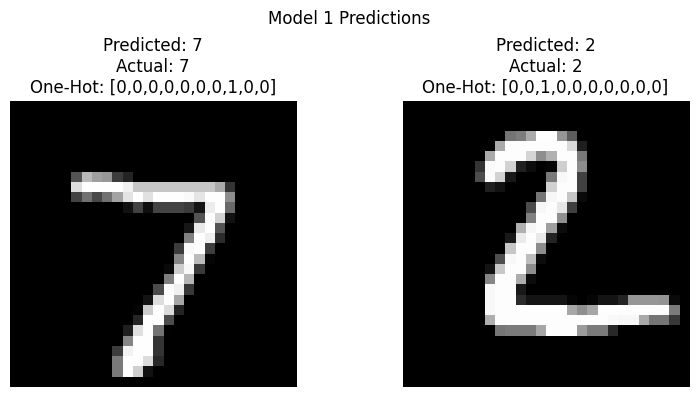


MODEL 2 RESULTS
Accuracy: 98.88 %
Loss: 0.033


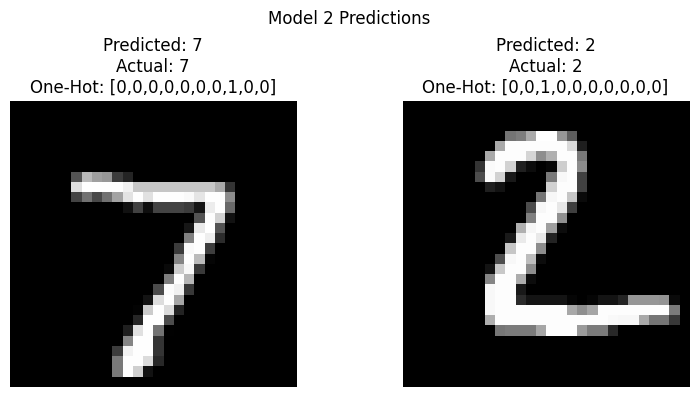

In [ ]:
```python
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.utils import to_categorical

(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

model1=Sequential([
    Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)),
    MaxPooling2D((2,2)),Flatten(),Dense(128,activation="relu"),
    Dense(10,activation="softmax")
])
model1.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])
model1.fit(x_train,y_train,epochs=5,batch_size=64,verbose=0)
loss1,accuracy1=model1.evaluate(x_test,y_test,verbose=0)

model2=Sequential([
    Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)),
    MaxPooling2D((2,2)),Conv2D(64,(3,3),activation="relu"),
    MaxPooling2D((2,2)),Flatten(),Dense(128,activation="relu"),
    Dense(10,activation="softmax")
])
model2.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])
model2.fit(x_train,y_train,epochs=5,batch_size=64,verbose=0)
loss2,accuracy2=model2.evaluate(x_test,y_test,verbose=0)

pred1=model1.predict(x_test[:2],verbose=0)
pred2=model2.predict(x_test[:2],verbose=0)

print("\nMODEL 1 RESULTS")
print("Accuracy:",round(accuracy1*100,2),"%")
print("Loss:",round(loss1,4))

plt.figure(figsize=(8,4))
for i in range(2):
    predicted=pred1[i].argmax()
    actual=y_test[i].argmax()
    vector_text="["+",".join(map(str,y_test[i].astype(int)))+"]"
    plt.subplot(1,2,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap="gray")
    plt.title(f"Predicted: {predicted}\nActual: {actual}\nOne-Hot: {vector_text}")
    plt.axis("off")
plt.suptitle("Model 1 Predictions")
plt.tight_layout()
plt.show()

print("\nMODEL 2 RESULTS")
print("Accuracy:",round(accuracy2*100,2),"%")
print("Loss:",round(loss2,4))

plt.figure(figsize=(8,4))
for i in range(2):
    predicted=pred2[i].argmax()
    actual=y_test[i].argmax()
    vector_text="["+",".join(map(str,y_test[i].astype(int)))+"]"
    plt.subplot(1,2,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap="gray")
    plt.title(f"Predicted: {predicted}\nActual: {actual}\nOne-Hot: {vector_text}")
    plt.axis("off")
plt.suptitle("Model 2 Predictions")
plt.tight_layout()
plt.show()
```
